<a href="https://colab.research.google.com/github/VyshnaviSekhar/Stroke-detection/blob/main/final_brain_stroke_main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os, random, cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.optimizers import AdamW
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TF Version:", tf.__version__)


In [ ]:
path = kagglehub.dataset_download("ozguraslank/brain-stroke-ct-dataset")
dataset_path = os.path.join(path, "Brain_Stroke_CT_Dataset")

class_names = ["Normal", "Ischemia", "Bleeding"]

image_paths, labels = [], []

for cls in class_names:
    folder = os.path.join(dataset_path, cls, "PNG")
    for f in os.listdir(folder):
        if f.endswith(".png"):
            image_paths.append(os.path.join(folder, f))
            labels.append(cls)

print("Total images:", len(image_paths))
for c in class_names:
    print(c, labels.count(c))


100%|██████████| 1.41G/1.41G [00:38<00:00, 39.0MB/s]

Extracting files...


Total images: 6650
Normal 4427
Ischemia 1130
Bleeding 1093


In [ ]:
le = LabelEncoder()
labels_enc = le.fit_transform(labels)
labels_cat = to_categorical(labels_enc)

train_paths, test_paths, y_train, y_test = train_test_split(
    image_paths,
    labels_cat,
    test_size=0.2,
    stratify=labels_enc,
    random_state=SEED
)

train_paths = np.array(train_paths)
test_paths = np.array(test_paths)
y_train = np.array(y_train, dtype=np.float32)
y_test = np.array(y_test, dtype=np.float32)


In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = 300

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)
    return img, label


In [ ]:
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.2),
])

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, y_train))
train_ds = train_ds.shuffle(2000, seed=SEED)
train_ds = train_ds.map(load_image, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(lambda x, y: (augment(x, training=True), y))
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, y_test))
test_ds = test_ds.map(load_image, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


In [ ]:
y_classes = np.argmax(y_train, axis=1)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_classes),
    y=y_classes
)
class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)


{0: np.float64(2.028985507246377), 1: np.float64(1.9616519174041298), 2: np.float64(0.5006587615283268)}


In [ ]:
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model

base_model = EfficientNetB3(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)

x = Dense(512, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(256, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

outputs = Dense(3, activation="softmax")(x)

model = Model(inputs, outputs)


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
model.compile(
    optimizer=AdamW(learning_rate=3e-4, weight_decay=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,705,650 (44.65 MB)

 Trainable params: 920,579 (3.51 MB)

 Non-trainable params: 10,785,071 (41.14 MB)

In [ ]:
callbacks1 = [
    ModelCheckpoint("best_phase1.keras", monitor="val_accuracy", save_best_only=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3),
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
]

history1 = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=callbacks1
)


Epoch 1/15
333/333 ━━━━━━━━━━━━━━━━━━━━ 256s 610ms/step - accuracy: 0.4535 - loss: 1.4988 - val_accuracy: 0.7662 - val_loss: 0.7171 - learning_rate: 3.0000e-04
Epoch 2/15
333/333 ━━━━━━━━━━━━━━━━━━━━ 148s 446ms/step - accuracy: 0.5962 - loss: 1.0524 - val_accuracy: 0.7692 - val_loss: 0.6978 - learning_rate: 3.0000e-04
Epoch 3/15
333/333 ━━━━━━━━━━━━━━━━━━━━ 149s 446ms/step - accuracy: 0.5961 - loss: 1.0218 - val_accuracy: 0.7887 - val_loss: 0.6942 - learning_rate: 3.0000e-04
Epoch 4/15
333/333 ━━━━━━━━━━━━━━━━━━━━ 153s 461ms/step - accuracy: 0.6354 - loss: 0.9120 - val_accuracy: 0.7947 - val_loss: 0.6672 - learning_rate: 3.0000e-04
Epoch 5/15
333/333 ━━━━━━━━━━━━━━━━━━━━ 196s 442ms/step - accuracy: 0.6597 - loss: 0.8997 - val_accuracy: 0.7947 - val_loss: 0.6516 - learning_rate: 3.0000e-04
Epoch 6/15
333/333 ━━━━━━━━━━━━━━━━━━━━ 147s 441ms/step - accuracy: 0.6807 - loss: 0.8522 - val_accuracy: 0.7774 - val_loss: 0.6756 - learning_rate: 3.0000e-04
Epoch 7/15
333/333 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
base_model.trainable = True

fine_tune_at = int(len(base_model.layers) * 0.7)

for i, layer in enumerate(base_model.layers):
    layer.trainable = i >= fine_tune_at
model.compile(
    optimizer=AdamW(learning_rate=1e-5, weight_decay=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)


In [ ]:
callbacks2 = [
    ModelCheckpoint("best_finetune.keras", monitor="val_accuracy", save_best_only=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3),
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
]

history2 = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=25,
    class_weight=class_weight_dict,
    callbacks=callbacks2
)


Epoch 1/25
333/333 ━━━━━━━━━━━━━━━━━━━━ 277s 627ms/step - accuracy: 0.6374 - loss: 0.9370 - val_accuracy: 0.7564 - val_loss: 0.7458 - learning_rate: 1.0000e-05
Epoch 2/25
333/333 ━━━━━━━━━━━━━━━━━━━━ 156s 466ms/step - accuracy: 0.6842 - loss: 0.8140 - val_accuracy: 0.7564 - val_loss: 0.7248 - learning_rate: 1.0000e-05
Epoch 3/25
333/333 ━━━━━━━━━━━━━━━━━━━━ 157s 471ms/step - accuracy: 0.7131 - loss: 0.7574 - val_accuracy: 0.7902 - val_loss: 0.6822 - learning_rate: 1.0000e-05
Epoch 4/25
333/333 ━━━━━━━━━━━━━━━━━━━━ 159s 476ms/step - accuracy: 0.7223 - loss: 0.7410 - val_accuracy: 0.8128 - val_loss: 0.6431 - learning_rate: 1.0000e-05
Epoch 5/25
333/333 ━━━━━━━━━━━━━━━━━━━━ 158s 475ms/step - accuracy: 0.7446 - loss: 0.7190 - val_accuracy: 0.8278 - val_loss: 0.6224 - learning_rate: 1.0000e-05
Epoch 6/25
333/333 ━━━━━━━━━━━━━━━━━━━━ 157s 472ms/step - accuracy: 0.7578 - loss: 0.6800 - val_accuracy: 0.8421 - val_loss: 0.5997 - learning_rate: 1.0000e-05
Epoch 7/25
333/333 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
loss, acc = model.evaluate(test_ds)
print(f"Final Test Accuracy: {acc*100:.2f}%")


84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.9053 - loss: 0.4955
Final Test Accuracy: 90.38%


Prediction probs: [0.00480381 0.05240291 0.9427933 ]
Predicted: Normal
True: Normal


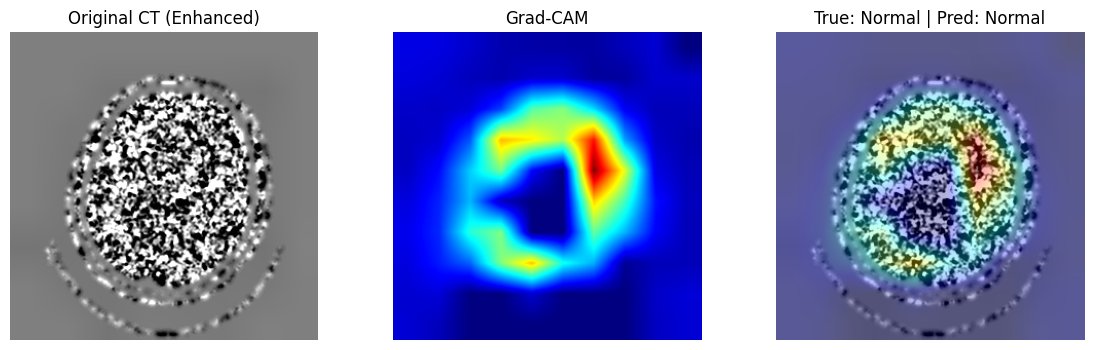

In [ ]:
# ===== FINAL GRAD-CAM WITH CLEAR CT VISUALIZATION =====
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
import random

# ------------------------------------------------------------
# STEP 1: Pick a random test image
# ------------------------------------------------------------
test_images, test_labels = [], []
for imgs, lbls in test_ds:
    test_images.extend(imgs.numpy())
    test_labels.extend(lbls.numpy())

idx = random.randint(0, len(test_images) - 1)
img = test_images[idx]
true_label = np.argmax(test_labels[idx])

img_input = tf.convert_to_tensor(img[None, ...], dtype=tf.float32)

# ------------------------------------------------------------
# STEP 2: Prediction
# ------------------------------------------------------------
preds = model(img_input, training=False)
pred_class = tf.argmax(preds[0]).numpy()

print("Prediction probs:", preds[0].numpy())
print("Predicted:", le.inverse_transform([pred_class])[0])
print("True:", le.inverse_transform([true_label])[0])

# ------------------------------------------------------------
# STEP 3: Forward pass manually (Keras-3 safe)
# ------------------------------------------------------------
base_model = model.get_layer("efficientnetb3")

with tf.GradientTape() as tape:
    conv_outputs = base_model(img_input, training=False)
    tape.watch(conv_outputs)

    x = model.get_layer("global_average_pooling2d")(conv_outputs)
    x = model.get_layer("dense")(x)
    x = model.get_layer("batch_normalization")(x)
    x = model.get_layer("dropout")(x)
    x = model.get_layer("dense_1")(x)
    x = model.get_layer("batch_normalization_1")(x)
    x = model.get_layer("dropout_1")(x)
    predictions = model.get_layer("dense_2")(x)

    loss = predictions[:, pred_class]

# ------------------------------------------------------------
# STEP 4: Compute Grad-CAM heatmap
# ------------------------------------------------------------
grads = tape.gradient(loss, conv_outputs)
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

conv_outputs = conv_outputs[0]
heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

heatmap = tf.maximum(heatmap, 0)
heatmap /= tf.reduce_max(heatmap) + 1e-8
heatmap = heatmap.numpy()

# ------------------------------------------------------------
# STEP 5: Resize & colorize heatmap
# ------------------------------------------------------------
heatmap = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
heatmap_uint8 = np.uint8(255 * heatmap)
heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

# ------------------------------------------------------------
# STEP 6: CLEAR CT IMAGE USING CLAHE (Radiology-style)
# ------------------------------------------------------------
# ------------------------------------------------------------
# STEP 6: MEDICAL-GRADE CT DENOISING + ENHANCEMENT
# ------------------------------------------------------------

# Convert from [-1,1] → [0,255]
ct = ((img + 1.0) * 127.5).astype(np.uint8)

# Convert to grayscale
ct_gray = cv2.cvtColor(ct, cv2.COLOR_RGB2GRAY)

# 1️⃣ Bilateral filter (edge-preserving denoise)
ct_denoised = cv2.bilateralFilter(
    ct_gray,
    d=9,
    sigmaColor=75,
    sigmaSpace=75
)

# 2️⃣ Gaussian smoothing (reduce grain)
ct_smooth = cv2.GaussianBlur(ct_denoised, (5, 5), 0)

# 3️⃣ Soft windowing (contrast stretch)
p5, p95 = np.percentile(ct_smooth, (5, 95))
ct_windowed = np.clip(
    (ct_smooth - p5) * 255.0 / (p95 - p5),
    0,
    255
).astype(np.uint8)

# 4️⃣ Gentle CLAHE (low clip limit to avoid noise)
clahe = cv2.createCLAHE(clipLimit=1.2, tileGridSize=(8, 8))
ct_final = clahe.apply(ct_windowed)

# Convert back to RGB
display_img = cv2.cvtColor(ct_final, cv2.COLOR_GRAY2RGB)

# Overlay Grad-CAM
overlay = cv2.addWeighted(display_img, 0.7, heatmap_color, 0.3, 0)


# ------------------------------------------------------------
# STEP 7: Visualization
# ------------------------------------------------------------
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.imshow(display_img)
plt.title("Original CT (Enhanced)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap_color[..., ::-1])
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay[..., ::-1])
plt.title(
    f"True: {le.inverse_transform([true_label])[0]} | "
    f"Pred: {le.inverse_transform([pred_class])[0]}"
)
plt.axis("off")

plt.show()


In [ ]:
model.save("stroke_model.keras")
np.save("labels.npy", le.classes_)

In [ ]:
!ls


best_finetune.keras  labels.npy   stroke_model.keras
best_phase1.keras    sample_data


In [ ]:
from google.colab import files

files.download("stroke_model.keras")
files.download("labels.npy")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>